# NEW Training â€” PGCF & Baselines (Combined Dataset + All Optimizations)

**Dataset:** Combined-32frames (Celeb-DF-v2 + FaceForensics++ C23) â€” Balanced

**Models saved to:** `newmodels/`

In [1]:
# Cell 1: Setup
import os, gc, time, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import cv2

cv2.setNumThreads(0)
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

from dataset import get_precomputed_dataset_splits, PrecomputedTensorDataset
from model import NormalCNN, ResNet50Baseline, PGCF
from loss import PGCFLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('=' * 50)
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print('=' * 50)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SAVE_DIR = 'newmodels'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Models saved to: {os.path.abspath(SAVE_DIR)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.0 GB
Models saved to: c:\deepfake\newmodels


In [2]:
# Cell 2: Load Combined Balanced Dataset
ROOT_DIR = 'Combined-32frames-tensors'
NUM_FRAMES = 32

train_split, val_split, test_split = get_precomputed_dataset_splits(
    ROOT_DIR, val_ratio=0.15, test_ratio=0.15, seed=SEED
)

def count_labels(s):
    r = sum(1 for _, l in s if l == 1)
    f = sum(1 for _, l in s if l == 0)
    return r, f

for name, sp in [('Train', train_split), ('Val', val_split), ('Test', test_split)]:
    r, f = count_labels(sp)
    print(f'{name:6s}: {len(sp):5d} videos  (Real: {r}, Fake: {f})')
print(f'Frames/video: {NUM_FRAMES}')

Precomputed Dataset: 1464 Real, 1464 Fake tensors available.
Train :  2050 videos  (Real: 1025, Fake: 1025)
Val   :   438 videos  (Real: 219, Fake: 219)
Test  :   440 videos  (Real: 220, Fake: 220)
Frames/video: 32


In [3]:
# Cell 3: DataLoaders
BATCH_SIZE = 2
ACCUM_STEPS = 4

train_dataset = PrecomputedTensorDataset(ROOT_DIR, train_split, augment=True)
val_dataset   = PrecomputedTensorDataset(ROOT_DIR, val_split,augment=False)
test_dataset  = PrecomputedTensorDataset(ROOT_DIR, test_split,augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

spatial, freq, rppg, label = next(iter(train_loader))
print(f'Spatial: {spatial.shape}, Freq: {freq.shape}, rPPG: {rppg.shape}, Label: {label.shape}')

Spatial: torch.Size([2, 32, 3, 224, 224]), Freq: torch.Size([2, 32, 4, 224, 224]), rPPG: torch.Size([2, 1, 32]), Label: torch.Size([2])


In [4]:
# Cell 4: Helpers
def get_gpu_mem():
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / 1024**2
        t = torch.cuda.get_device_properties(0).total_memory / 1024**2
        return f'{a:.0f}/{t:.0f} MB'
    return 'N/A'

def free_gpu():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache(); torch.cuda.synchronize()

def save_checkpoint(model, name, epoch, val_acc, val_auc=0.0):
    path = os.path.join(SAVE_DIR, f'{name}_e{epoch}_acc{val_acc:.1f}_auc{val_auc:.4f}.pth')
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'val_accuracy': val_acc, 'val_auc': val_auc}, path)
    print(f'  -> Saved: {path}')

def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ep = range(1, len(history['train_loss']) + 1)
    axes[0].plot(ep, history['train_loss'], 'b-o', ms=3, label='Train')
    axes[0].plot(ep, history['val_loss'], 'r-o', ms=3, label='Val')
    axes[0].set_title(f'{title} â€” Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history['val_acc'], 'g-o', ms=3); axes[1].set_title(f'{title} â€” Val Acc (%)'); axes[1].grid(alpha=0.3)
    axes[2].plot(ep, history['val_auc'], 'm-o', ms=3); axes[2].set_title(f'{title} â€” Val AUC'); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{title.replace(" ","_")}_curves.png'), dpi=100)
    plt.show()

def compute_auc(model, loader, is_pgcf=False):
    model.eval()
    probs, labs = [], []
    with torch.no_grad():
        for sp, fq, rp, lb in loader:
            sp = sp.to(device)
            with autocast('cuda'):
                if is_pgcf: out, _, _ = model(sp, fq.to(device), rp.to(device))
                else: out = model(sp)
            probs.extend(torch.softmax(out.float(), 1)[:, 1].cpu().numpy())
            labs.extend(lb.numpy())
    try: return roc_auc_score(labs, probs)
    except: return 0.0

print('Helpers ready.')

Helpers ready.


---
## Model 1: Normal CNN (8 epochs)

In [5]:
# Cell 5: Train Normal CNN
free_gpu()
model_cnn = NormalCNN().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=4, T_mult=2)
scaler = GradScaler('cuda')

NUM_EPOCHS = 8
PATIENCE = 4
hist = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_auc, no_imp = 0.0, 0

print(f'Training Normal CNN ({NUM_EPOCHS} epochs)')
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model_cnn.train()
    rl, cor, tot = 0.0, 0, 0
    optimizer.zero_grad()
    for step, (sp, _, _, lb) in enumerate(train_loader, 1):
        sp, lb = sp.to(device), lb.to(device)
        with autocast('cuda'):
            out = model_cnn(sp); loss = criterion(out, lb) / ACCUM_STEPS
        scaler.scale(loss).backward()
        if step % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_cnn.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
        rl += loss.item() * ACCUM_STEPS * sp.size(0)
        cor += (torch.argmax(out, 1) == lb).sum().item(); tot += lb.size(0)
        if step % 200 == 0:
            print(f'  E{epoch} Step {step}/{len(train_loader)} | Loss: {rl/tot:.4f} | Acc: {100*cor/tot:.1f}%')
    if step % ACCUM_STEPS != 0:
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model_cnn.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
    scheduler.step()
    tl = rl / tot
    # Val
    model_cnn.eval(); vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for sp, _, _, lb in val_loader:
            sp, lb = sp.to(device), lb.to(device)
            with autocast('cuda'): out = model_cnn(sp); loss = criterion(out, lb)
            vl += loss.item() * sp.size(0); vc += (torch.argmax(out,1)==lb).sum().item(); vt += lb.size(0)
    va, vacc = vl/vt, 100*vc/vt
    vauc = compute_auc(model_cnn, val_loader)
    hist['train_loss'].append(tl); hist['val_loss'].append(va); hist['val_acc'].append(vacc); hist['val_auc'].append(vauc)
    print(f'Epoch {epoch}/{NUM_EPOCHS} | TrL: {tl:.4f} | VaL: {va:.4f} | VaAcc: {vacc:.1f}% | AUC: {vauc:.4f} | {time.time()-t0:.0f}s')
    if vauc > best_auc: best_auc = vauc; save_checkpoint(model_cnn, 'CNN_best', epoch, vacc, vauc); no_imp = 0
    else:
        no_imp += 1
        if no_imp >= PATIENCE: print('Early stop!'); break
save_checkpoint(model_cnn, 'CNN_final', epoch, vacc, vauc)
cnn_history = hist
print(f'CNN Best AUC: {best_auc:.4f}')

Training Normal CNN (8 epochs)
----------------------------------------------------------------------
  E1 Step 200/1025 | Loss: 0.7182 | Acc: 47.2%
  E1 Step 400/1025 | Loss: 0.7076 | Acc: 49.6%
  E1 Step 600/1025 | Loss: 0.7038 | Acc: 52.0%
  E1 Step 800/1025 | Loss: 0.6997 | Acc: 53.2%
  E1 Step 1000/1025 | Loss: 0.6972 | Acc: 53.8%
Epoch 1/8 | TrL: 0.6974 | VaL: 0.7598 | VaAcc: 50.7% | AUC: 0.5502 | 340s
  -> Saved: newmodels\CNN_best_e1_acc50.7_auc0.5502.pth
  E2 Step 200/1025 | Loss: 0.6948 | Acc: 56.0%
  E2 Step 400/1025 | Loss: 0.6950 | Acc: 53.8%
  E2 Step 600/1025 | Loss: 0.6929 | Acc: 54.2%
  E2 Step 800/1025 | Loss: 0.6901 | Acc: 55.1%
  E2 Step 1000/1025 | Loss: 0.6915 | Acc: 54.8%
Epoch 2/8 | TrL: 0.6915 | VaL: 0.6926 | VaAcc: 56.4% | AUC: 0.5567 | 302s
  -> Saved: newmodels\CNN_best_e2_acc56.4_auc0.5567.pth
  E3 Step 200/1025 | Loss: 0.6892 | Acc: 54.8%
  E3 Step 400/1025 | Loss: 0.6898 | Acc: 53.8%
  E3 Step 600/1025 | Loss: 0.6886 | Acc: 54.4%
  E3 Step 800/1025 | Loss

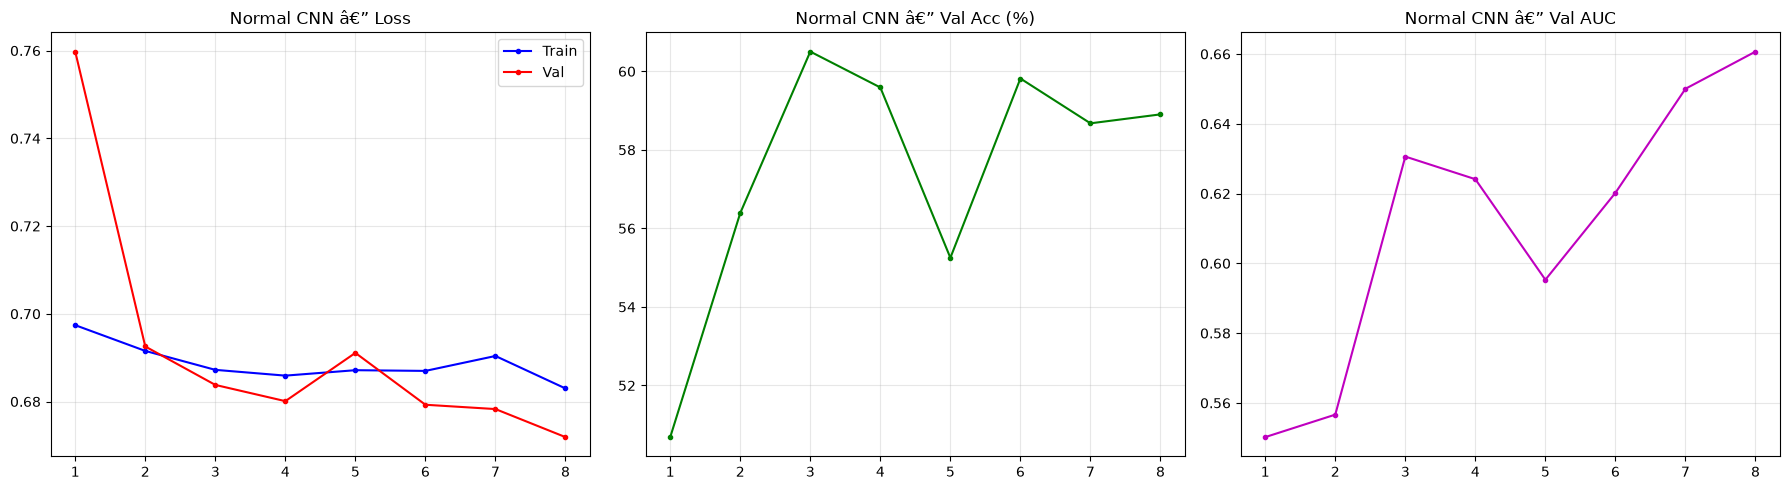

In [6]:
plot_history(cnn_history, 'Normal CNN')

In [7]:
del model_cnn, optimizer, scaler, criterion, scheduler; free_gpu()
print(f'GPU: {get_gpu_mem()}')

GPU: 53/6140 MB


---
## Model 2: ResNet50 (8 epochs)

In [8]:
# Cell 8: Train ResNet50
free_gpu()
model_resnet = ResNet50Baseline(pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=4, T_mult=2)
scaler = GradScaler('cuda')

NUM_EPOCHS = 8
PATIENCE = 4
hist = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_auc, no_imp = 0.0, 0

print(f'Training ResNet50 ({NUM_EPOCHS} epochs)')
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model_resnet.train()
    rl, cor, tot = 0.0, 0, 0
    optimizer.zero_grad()
    for step, (sp, _, _, lb) in enumerate(train_loader, 1):
        sp, lb = sp.to(device), lb.to(device)
        with autocast('cuda'):
            out = model_resnet(sp); loss = criterion(out, lb) / ACCUM_STEPS
        scaler.scale(loss).backward()
        if step % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_resnet.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
        rl += loss.item() * ACCUM_STEPS * sp.size(0)
        cor += (torch.argmax(out, 1) == lb).sum().item(); tot += lb.size(0)
        if step % 200 == 0:
            print(f'  E{epoch} Step {step}/{len(train_loader)} | Loss: {rl/tot:.4f} | Acc: {100*cor/tot:.1f}%')
    if step % ACCUM_STEPS != 0:
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model_resnet.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
    scheduler.step()
    tl = rl / tot
    model_resnet.eval(); vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for sp, _, _, lb in val_loader:
            sp, lb = sp.to(device), lb.to(device)
            with autocast('cuda'): out = model_resnet(sp); loss = criterion(out, lb)
            vl += loss.item() * sp.size(0); vc += (torch.argmax(out,1)==lb).sum().item(); vt += lb.size(0)
    va, vacc = vl/vt, 100*vc/vt
    vauc = compute_auc(model_resnet, val_loader)
    hist['train_loss'].append(tl); hist['val_loss'].append(va); hist['val_acc'].append(vacc); hist['val_auc'].append(vauc)
    print(f'Epoch {epoch}/{NUM_EPOCHS} | TrL: {tl:.4f} | VaL: {va:.4f} | VaAcc: {vacc:.1f}% | AUC: {vauc:.4f} | {time.time()-t0:.0f}s')
    if vauc > best_auc: best_auc = vauc; save_checkpoint(model_resnet, 'ResNet50_best', epoch, vacc, vauc); no_imp = 0
    else:
        no_imp += 1
        if no_imp >= PATIENCE: print('Early stop!'); break
save_checkpoint(model_resnet, 'ResNet50_final', epoch, vacc, vauc)
resnet_history = hist
print(f'ResNet50 Best AUC: {best_auc:.4f}')

Training ResNet50 (8 epochs)
----------------------------------------------------------------------
  E1 Step 200/1025 | Loss: 0.6837 | Acc: 59.0%
  E1 Step 400/1025 | Loss: 0.6678 | Acc: 61.5%
  E1 Step 600/1025 | Loss: 0.6515 | Acc: 63.4%
  E1 Step 800/1025 | Loss: 0.6436 | Acc: 64.6%
  E1 Step 1000/1025 | Loss: 0.6432 | Acc: 64.5%
Epoch 1/8 | TrL: 0.6437 | VaL: 0.5572 | VaAcc: 74.7% | AUC: 0.8294 | 481s
  -> Saved: newmodels\ResNet50_best_e1_acc74.7_auc0.8294.pth
  E2 Step 200/1025 | Loss: 0.5615 | Acc: 75.2%
  E2 Step 400/1025 | Loss: 0.5527 | Acc: 75.0%
  E2 Step 600/1025 | Loss: 0.5524 | Acc: 75.8%
  E2 Step 800/1025 | Loss: 0.5537 | Acc: 75.0%
  E2 Step 1000/1025 | Loss: 0.5519 | Acc: 75.4%
Epoch 2/8 | TrL: 0.5520 | VaL: 0.6351 | VaAcc: 69.6% | AUC: 0.8493 | 483s
  -> Saved: newmodels\ResNet50_best_e2_acc69.6_auc0.8493.pth
  E3 Step 200/1025 | Loss: 0.5049 | Acc: 79.5%
  E3 Step 400/1025 | Loss: 0.4827 | Acc: 80.4%
  E3 Step 600/1025 | Loss: 0.4714 | Acc: 81.8%
  E3 Step 800/102

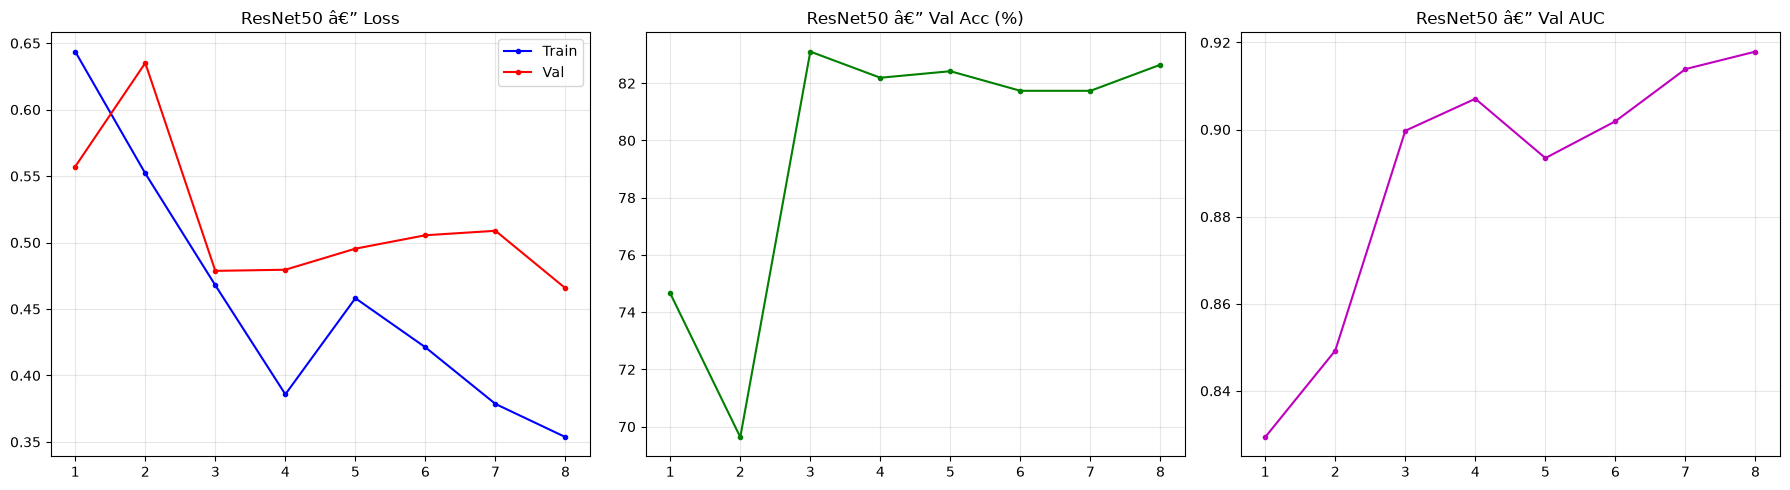

In [9]:
plot_history(resnet_history, 'ResNet50')

In [10]:
del model_resnet, optimizer, scaler, criterion, scheduler; free_gpu()
print(f'GPU: {get_gpu_mem()}')

GPU: 53/6140 MB


---
## Model 3: PGCF â€” Phase 1 (5 epochs, frozen backbone) + Phase 2 (8 epochs, unfrozen)

In [12]:
# Cell 11: PGCF Phase 1 â€” Frozen Backbone
free_gpu()
PGCF_BATCH = 1; PGCF_ACCUM = 8

pgcf_train_loader = DataLoader(train_dataset, batch_size=PGCF_BATCH, shuffle=True,  num_workers=0, pin_memory=False)
pgcf_val_loader   = DataLoader(val_dataset,   batch_size=PGCF_BATCH, shuffle=False, num_workers=0, pin_memory=False)

model_pgcf = PGCF(num_frames=NUM_FRAMES, pretrained=True).to(device)

# Freeze backbone
for p in model_pgcf.spatial_backbone.parameters(): p.requires_grad = False

trainable = [p for p in model_pgcf.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable, lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=3, T_mult=2)
loss_fn = PGCFLoss(alpha=0.0, beta=0.0)
loss_fn.cls_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler('cuda')

P1_EPOCHS = 5; WARMUP = 3
pgcf_hist = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_pgcf_auc = 0.0; total_ep = 0

print(f'PGCF Phase 1: Backbone FROZEN ({P1_EPOCHS} epochs)')
print('-' * 70)

for epoch in range(1, P1_EPOCHS + 1):
    total_ep += 1; t0 = time.time()
    # Loss warmup
    if total_ep <= WARMUP:
        loss_fn.alpha = 0.3 * (total_ep / WARMUP)
        loss_fn.beta = 0.1 * (total_ep / WARMUP)
    else: loss_fn.alpha = 0.3; loss_fn.beta = 0.1
    
    model_pgcf.train()
    rl, rc, rcon, rrp, cor, tot = 0., 0., 0., 0., 0, 0
    optimizer.zero_grad()
    for step, (sp, fq, rp, lb) in enumerate(pgcf_train_loader, 1):
        sp, fq, rp, lb = sp.to(device), fq.to(device), rp.to(device), lb.to(device)
        with autocast('cuda'):
            logits, s, rr = model_pgcf(sp, fq, rp)
            loss, comps = loss_fn(logits, lb, s, rr, rp)
            loss = loss / PGCF_ACCUM
        scaler.scale(loss).backward()
        if step % PGCF_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_pgcf.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
        rl += comps['loss_total']*sp.size(0); rc += comps['loss_cls']*sp.size(0)
        rcon += comps['loss_consist']*sp.size(0); rrp += comps['loss_rppg']*sp.size(0)
        cor += (torch.argmax(logits,1)==lb).sum().item(); tot += lb.size(0)
        if step % 300 == 0:
            print(f'  P1-E{epoch} Step {step}/{len(pgcf_train_loader)} | '
                  f'Tot: {rl/tot:.4f} CLS: {rc/tot:.4f} Con: {rcon/tot:.4f} rPPG: {rrp/tot:.4f} | '
                  f'Acc: {100*cor/tot:.1f}% | GPU: {get_gpu_mem()}')
    if step % PGCF_ACCUM != 0:
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model_pgcf.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
    scheduler.step()
    tl = rl / tot
    # Val
    model_pgcf.eval(); vl, vc, vt = 0., 0, 0
    with torch.no_grad():
        for sp, fq, rp, lb in pgcf_val_loader:
            sp, fq, rp, lb = sp.to(device), fq.to(device), rp.to(device), lb.to(device)
            with autocast('cuda'):
                logits, s, rr = model_pgcf(sp, fq, rp)
                loss, _ = loss_fn(logits, lb, s, rr, rp)
            vl += loss.item()*sp.size(0); vc += (torch.argmax(logits,1)==lb).sum().item(); vt += lb.size(0)
    va, vacc = vl/vt, 100*vc/vt
    vauc = compute_auc(model_pgcf, pgcf_val_loader, is_pgcf=True)
    pgcf_hist['train_loss'].append(tl); pgcf_hist['val_loss'].append(va)
    pgcf_hist['val_acc'].append(vacc); pgcf_hist['val_auc'].append(vauc)
    print(f'P1 E{epoch}/{P1_EPOCHS} | TrL: {tl:.4f} | VaL: {va:.4f} | VaAcc: {vacc:.1f}% | AUC: {vauc:.4f} | '
          f'a={loss_fn.alpha:.2f} b={loss_fn.beta:.2f} | {time.time()-t0:.0f}s')
    if vauc > best_pgcf_auc: best_pgcf_auc = vauc; save_checkpoint(model_pgcf, 'PGCF_best', total_ep, vacc, vauc)
    free_gpu()
print(f'Phase 1 Done. Best AUC: {best_pgcf_auc:.4f}')

PGCF Phase 1: Backbone FROZEN (5 epochs)
----------------------------------------------------------------------
  P1-E1 Step 300/2050 | Tot: 0.8708 CLS: 0.7866 Con: 0.5083 rPPG: 1.0017 | Acc: 52.0% | GPU: 837/6140 MB
  P1-E1 Step 600/2050 | Tot: 0.8359 CLS: 0.7522 Con: 0.5039 rPPG: 1.0004 | Acc: 48.7% | GPU: 809/6140 MB
  P1-E1 Step 900/2050 | Tot: 0.8259 CLS: 0.7422 Con: 0.5049 rPPG: 0.9978 | Acc: 48.7% | GPU: 837/6140 MB
  P1-E1 Step 1200/2050 | Tot: 0.8167 CLS: 0.7331 Con: 0.5043 rPPG: 0.9942 | Acc: 48.5% | GPU: 809/6140 MB
  P1-E1 Step 1500/2050 | Tot: 0.8108 CLS: 0.7274 Con: 0.5036 rPPG: 0.9905 | Acc: 48.0% | GPU: 837/6140 MB
  P1-E1 Step 1800/2050 | Tot: 0.8059 CLS: 0.7230 Con: 0.5032 rPPG: 0.9767 | Acc: 48.3% | GPU: 809/6140 MB
P1 E1/5 | TrL: 0.8043 | VaL: 0.8214 | VaAcc: 50.0% | AUC: 0.5091 | a=0.10 b=0.03 | 443s
  -> Saved: newmodels\PGCF_best_e1_acc50.0_auc0.5091.pth
  P1-E2 Step 300/2050 | Tot: 0.8641 CLS: 0.7046 Con: 0.5134 rPPG: 0.8518 | Acc: 53.7% | GPU: 837/6140 MB
  P1-

In [13]:
# Cell 12: PGCF Phase 2 â€” All Unfrozen
for p in model_pgcf.spatial_backbone.parameters(): p.requires_grad = True

optimizer = torch.optim.AdamW([
    {'params': model_pgcf.spatial_backbone.parameters(), 'lr': 1e-5},
    {'params': [p for n, p in model_pgcf.named_parameters() if 'spatial_backbone' not in n], 'lr': 5e-4}
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=4, T_mult=2)
scaler = GradScaler('cuda')
loss_fn.alpha = 0.3; loss_fn.beta = 0.1

P2_EPOCHS = 8; PATIENCE = 4; no_imp = 0

print(f'\nPGCF Phase 2: ALL UNFROZEN ({P2_EPOCHS} epochs)')
print(f'Backbone LR: 1e-5 | New layers LR: 5e-4')
print('-' * 70)

for epoch in range(1, P2_EPOCHS + 1):
    total_ep += 1; t0 = time.time()
    model_pgcf.train()
    rl, rc, rcon, rrp, cor, tot = 0., 0., 0., 0., 0, 0
    optimizer.zero_grad()
    for step, (sp, fq, rp, lb) in enumerate(pgcf_train_loader, 1):
        sp, fq, rp, lb = sp.to(device), fq.to(device), rp.to(device), lb.to(device)
        with autocast('cuda'):
            logits, s, rr = model_pgcf(sp, fq, rp)
            loss, comps = loss_fn(logits, lb, s, rr, rp)
            loss = loss / PGCF_ACCUM
        scaler.scale(loss).backward()
        if step % PGCF_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_pgcf.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
        rl += comps['loss_total']*sp.size(0); rc += comps['loss_cls']*sp.size(0)
        rcon += comps['loss_consist']*sp.size(0); rrp += comps['loss_rppg']*sp.size(0)
        cor += (torch.argmax(logits,1)==lb).sum().item(); tot += lb.size(0)
        if step % 300 == 0:
            print(f'  P2-E{epoch} Step {step}/{len(pgcf_train_loader)} | '
                  f'Tot: {rl/tot:.4f} CLS: {rc/tot:.4f} Con: {rcon/tot:.4f} rPPG: {rrp/tot:.4f} | '
                  f'Acc: {100*cor/tot:.1f}% | GPU: {get_gpu_mem()}')
    if step % PGCF_ACCUM != 0:
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model_pgcf.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
    scheduler.step()
    tl = rl / tot
    model_pgcf.eval(); vl, vc, vt = 0., 0, 0
    with torch.no_grad():
        for sp, fq, rp, lb in pgcf_val_loader:
            sp, fq, rp, lb = sp.to(device), fq.to(device), rp.to(device), lb.to(device)
            with autocast('cuda'):
                logits, s, rr = model_pgcf(sp, fq, rp)
                loss, _ = loss_fn(logits, lb, s, rr, rp)
            vl += loss.item()*sp.size(0); vc += (torch.argmax(logits,1)==lb).sum().item(); vt += lb.size(0)
    va, vacc = vl/vt, 100*vc/vt
    vauc = compute_auc(model_pgcf, pgcf_val_loader, is_pgcf=True)
    pgcf_hist['train_loss'].append(tl); pgcf_hist['val_loss'].append(va)
    pgcf_hist['val_acc'].append(vacc); pgcf_hist['val_auc'].append(vauc)
    print(f'P2 E{epoch}/{P2_EPOCHS} | TrL: {tl:.4f} | VaL: {va:.4f} | VaAcc: {vacc:.1f}% | AUC: {vauc:.4f} | {time.time()-t0:.0f}s')
    if vauc > best_pgcf_auc: best_pgcf_auc = vauc; save_checkpoint(model_pgcf, 'PGCF_best', total_ep, vacc, vauc); no_imp = 0
    else:
        no_imp += 1
        if no_imp >= PATIENCE: print('Early stop!'); break
    free_gpu()
save_checkpoint(model_pgcf, 'PGCF_final', total_ep, vacc, vauc)
print(f'PGCF Done. Best AUC: {best_pgcf_auc:.4f}')


PGCF Phase 2: ALL UNFROZEN (8 epochs)
Backbone LR: 1e-5 | New layers LR: 5e-4
----------------------------------------------------------------------
  P2-E1 Step 300/2050 | Tot: 0.8823 CLS: 0.6956 Con: 0.3923 rPPG: 0.6900 | Acc: 53.3% | GPU: 1116/6140 MB
  P2-E1 Step 600/2050 | Tot: 0.8859 CLS: 0.6961 Con: 0.4042 rPPG: 0.6851 | Acc: 51.8% | GPU: 996/6140 MB
  P2-E1 Step 900/2050 | Tot: 0.8867 CLS: 0.6969 Con: 0.4017 rPPG: 0.6929 | Acc: 50.1% | GPU: 1116/6140 MB
  P2-E1 Step 1200/2050 | Tot: 0.8937 CLS: 0.7028 Con: 0.4045 rPPG: 0.6953 | Acc: 50.5% | GPU: 996/6140 MB
  P2-E1 Step 1500/2050 | Tot: 0.8910 CLS: 0.7012 Con: 0.4020 rPPG: 0.6927 | Acc: 52.0% | GPU: 1116/6140 MB
  P2-E1 Step 1800/2050 | Tot: 0.8874 CLS: 0.6988 Con: 0.3987 rPPG: 0.6902 | Acc: 52.7% | GPU: 996/6140 MB
P2 E1/8 | TrL: 0.8861 | VaL: 0.9060 | VaAcc: 66.4% | AUC: 0.6885 | 605s
  -> Saved: newmodels\PGCF_best_e6_acc66.4_auc0.6885.pth
  P2-E2 Step 300/2050 | Tot: 0.8263 CLS: 0.6575 Con: 0.3516 rPPG: 0.6332 | Acc: 63.0%

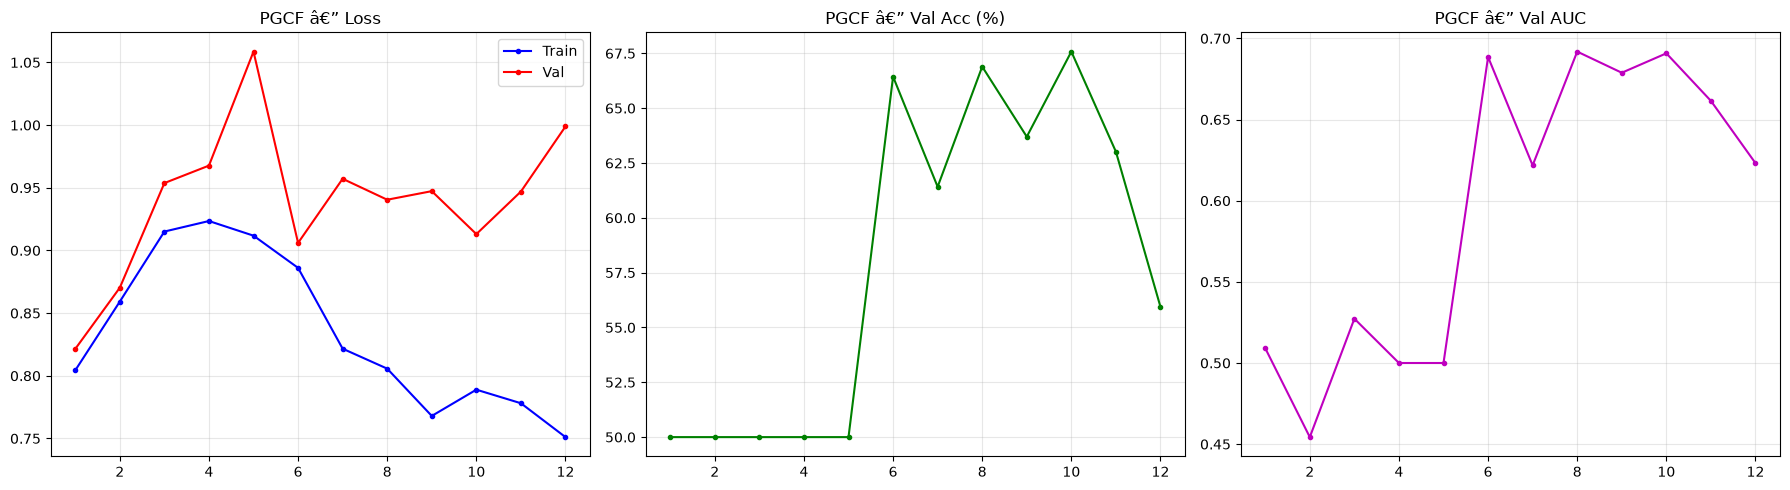

In [14]:
plot_history(pgcf_hist, 'PGCF')

---
## Evaluate All Models on Test Set (with TTA)

In [15]:
# Cell 15: Evaluation with TTA
def evaluate_tta(model, loader, name, is_pgcf=False):
    model.eval()
    preds_all, probs_all, labs_all = [], [], []
    with torch.no_grad():
        for sp, fq, rp, lb in loader:
            sp = sp.to(device)
            with autocast('cuda'):
                if is_pgcf: fq_d, rp_d = fq.to(device), rp.to(device); o1,_,_ = model(sp, fq_d, rp_d)
                else: o1 = model(sp)
            sp_f = torch.flip(sp, [-1])
            with autocast('cuda'):
                if is_pgcf: fq_f = torch.flip(fq_d, [-1]); o2,_,_ = model(sp_f, fq_f, rp_d)
                else: o2 = model(sp_f)
            avg = (o1 + o2) / 2
            probs_all.extend(torch.softmax(avg.float(), 1)[:, 1].cpu().numpy())
            preds_all.extend(torch.argmax(avg, 1).cpu().numpy())
            labs_all.extend(lb.numpy())
    acc = accuracy_score(labs_all, preds_all)
    prec = precision_score(labs_all, preds_all, zero_division=0)
    rec = recall_score(labs_all, preds_all, zero_division=0)
    f1 = f1_score(labs_all, preds_all, zero_division=0)
    try: auc = roc_auc_score(labs_all, probs_all)
    except: auc = 0.0
    print(f'\n{"="*45}\n  {name} â€” Test (TTA)\n{"="*45}')
    print(f'  Acc: {acc*100:.2f}% | Prec: {prec*100:.2f}% | Rec: {rec*100:.2f}% | F1: {f1*100:.2f}% | AUC: {auc:.4f}')
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

In [16]:
# Cell 16: Load Best & Evaluate
pgcf_test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

free_gpu()
m = NormalCNN().to(device)
ck = sorted([f for f in os.listdir(SAVE_DIR) if f.startswith('CNN_best')])
if ck: m.load_state_dict(torch.load(os.path.join(SAVE_DIR,ck[-1]),map_location=device,weights_only=True)['model_state_dict']); print(f'Loaded {ck[-1]}')
cnn_results = evaluate_tta(m, test_loader, 'Normal CNN')
del m; free_gpu()

m = ResNet50Baseline(pretrained=False).to(device)
ck = sorted([f for f in os.listdir(SAVE_DIR) if f.startswith('ResNet50_best')])
if ck: m.load_state_dict(torch.load(os.path.join(SAVE_DIR,ck[-1]),map_location=device,weights_only=True)['model_state_dict']); print(f'Loaded {ck[-1]}')
resnet_results = evaluate_tta(m, test_loader, 'ResNet50')
del m; free_gpu()

m = PGCF(num_frames=NUM_FRAMES, pretrained=False).to(device)
ck = sorted([f for f in os.listdir(SAVE_DIR) if f.startswith('PGCF_best')])
if ck: m.load_state_dict(torch.load(os.path.join(SAVE_DIR,ck[-1]),map_location=device,weights_only=True)['model_state_dict']); print(f'Loaded {ck[-1]}')
pgcf_results = evaluate_tta(m, pgcf_test_loader, 'PGCF (Paper)', is_pgcf=True)
del m; free_gpu()

Loaded CNN_best_e8_acc58.9_auc0.6607.pth

  Normal CNN â€” Test (TTA)
  Acc: 58.64% | Prec: 61.59% | Rec: 45.91% | F1: 52.60% | AUC: 0.6469
Loaded ResNet50_best_e8_acc82.6_auc0.9179.pth

  ResNet50 â€” Test (TTA)
  Acc: 79.32% | Prec: 74.71% | Rec: 88.64% | F1: 81.08% | AUC: 0.8899
Loaded PGCF_best_e8_acc66.9_auc0.6919.pth

  PGCF (Paper) â€” Test (TTA)
  Acc: 64.77% | Prec: 63.05% | Rec: 71.36% | F1: 66.95% | AUC: 0.6825


In [17]:
# Cell 17: Final Comparison
print('\n' + '=' * 75)
print(f'{"Model":<20} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"AUC":>10}')
print('=' * 75)
for n, r in [('Normal CNN', cnn_results), ('ResNet50', resnet_results), ('PGCF (Paper)', pgcf_results)]:
    print(f'{n:<20} {r["accuracy"]*100:>9.2f}% {r["precision"]*100:>9.2f}% '
          f'{r["recall"]*100:>9.2f}% {r["f1"]*100:>9.2f}% {r["auc"]:>9.4f}')
print('=' * 75)
print(f'Models in: {os.path.abspath(SAVE_DIR)}')


Model                  Accuracy  Precision     Recall         F1        AUC
Normal CNN               58.64%     61.59%     45.91%     52.60%    0.6469
ResNet50                 79.32%     74.71%     88.64%     81.08%    0.8899
PGCF (Paper)             64.77%     63.05%     71.36%     66.95%    0.6825
Models in: c:\deepfake\newmodels
